In [9]:
import os
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df = pd.read_excel(r"C:\Users\daves\Desktop\EduFlow\eduflow\evaluator_service\evaluation\evaluation_results.xlsx")
print(df.shape)
df

(18, 11)


,Job ID,Architecture,Input Parameters,Duration,Number of Docs,Completion Time,Total Input Tokens,Total Output Tokens,Custom Matrics,Rubric - LLM,Pairwise - LLM
0,job-1774534470161,Eduflow,"{""job_id"": ""job-1774534470161"", ""callback_url""...",5,4,223,39405,9973,"{\n ""document_count"": 4,\n ""metrics"": {\n ...","{""architecture"": ""architecture A"", ""runs"": 3, ...",none
1,job-1774534999912,Baseline 1,"{""job_id"": ""job-1774534999912"", ""callback_url""...",5,4,119,29572,5201,"{\n ""document_count"": 4,\n ""metrics"": {\n ...","{""architecture"": ""architecture A"", ""runs"": 3, ...","{""winner"": ""sequence_a"", ""win_counts"": {""seque..."
2,job-1774544649734,Baseline 2,"{""job_id"": ""job-1774544649734"", ""callback_url""...",5,4,152,38306,7520,"{\n ""document_count"": 4,\n ""metrics"": {\n ...","{""architecture"": ""architecture A"", ""runs"": 3, ...","{""winner"": ""sequence_a"", ""win_counts"": {""seque..."
3,job-1774545286253,Eduflow,"{""job_id"": ""job-1774545286253"", ""callback_url""...",5,4,214,38608,9541,"{\n ""document_count"": 4,\n ""metrics"": {\n ...","{""architecture"": ""architecture A"", ""runs"": 3, ...",none
4,job-1774545754239,Baseline 1,"{""job_id"": ""job-1774545754239"", ""callback_url""...",5,4,106,27969,4850,"{\n ""document_count"": 4,\n ""metrics"": {\n ...","{""architecture"": ""architecture A"", ""runs"": 3, ...","{""winner"": ""sequence_a"", ""win_counts"": {""seque..."
5,job-1774547498894,Baseline 2,"{""job_id"": ""job-1774547498894"", ""callback_url""...",5,4,151,36614,7286,"{\n ""document_count"": 4,\n ""metrics"": {\n ...","{""architecture"": ""architecture A"", ""runs"": 3, ...","{""winner"": ""sequence_a"", ""win_counts"": {""seque..."
6,job-1774548177351,Eduflow,"{""job_id"": ""job-1774548177351"", ""callback_url""...",5,4,227,40186,9799,"{\n ""document_count"": 4,\n ""metrics"": {\n ...","{""architecture"": ""architecture A"", ""runs"": 3, ...",none
7,job-1774548651030,Baseline 1,"{""job_id"": ""job-1774548651030"", ""callback_url""...",5,4,110,29479,4735,"{\n ""document_count"": 4,\n ""metrics"": {\n ...","{""architecture"": ""architecture A"", ""runs"": 3, ...","{""winner"": ""sequence_a"", ""win_counts"": {""seque..."
8,job-1774549026730,Baseline 2,"{""job_id"": ""job-1774549026730"", ""callback_url""...",5,4,153,38132,7318,"{\n ""document_count"": 4,\n ""metrics"": {\n ...","{""architecture"": ""architecture A"", ""runs"": 3, ...","{""winner"": ""sequence_a"", ""win_counts"": {""seque..."
9,job-1774574045744,Eduflow,"{""job_id"": ""job-1774574045744"", ""callback_url""...",5,4,224,40286,10107,"{\n ""document_count"": 4,\n ""metrics"": {\n ...","{""architecture"": ""architecture A"", ""runs"": 3, ...",none


In [4]:
print(df.dtypes)

Job ID                 object
Architecture           object
Input Parameters       object
Duration                int64
Number of Docs          int64
Completion Time         int64
Total Input Tokens      int64
Total Output Tokens     int64
Custom Matrics         object
Rubric - LLM           object
Pairwise - LLM         object
dtype: object


In [5]:
df["Set"] = (df.index // 3) + 1
print(df[["Set", "Job ID", "Architecture"]])

    Set             Job ID Architecture
0     1  job-1774534470161      Eduflow
1     1  job-1774534999912   Baseline 1
2     1  job-1774544649734   Baseline 2
3     2  job-1774545286253      Eduflow
4     2  job-1774545754239   Baseline 1
5     2  job-1774547498894   Baseline 2
6     3  job-1774548177351      Eduflow
7     3  job-1774548651030   Baseline 1
8     3  job-1774549026730   Baseline 2
9     4  job-1774574045744      Eduflow
10    4  job-1774574325545   Baseline 1
11    4  job-1774574626655   Baseline 2
12    5  job-1774590551422      Eduflow
13    5  job-1774584736262   Baseline 1
14    5  job-1774584969330   Baseline 2
15    6  job-1774596210500      Eduflow
16    6  job-1774595522117   Baseline 1
17    6  job-1774596683553   Baseline 2


In [ ]:
def safe_parse(val):
    try:
        return json.loads(val)
    except:
        return None

df["rubric_parsed"]   = df["Rubric - LLM"].apply(safe_parse)
df["pairwise_parsed"] = df["Pairwise - LLM"].apply(safe_parse)
df["custom_parsed"]   = df["Custom Matrics"].apply(safe_parse)

# Quick check — show what we got
for col in ["rubric_parsed", "pairwise_parsed", "custom_parsed"]:
    none_count = df[col].isna().sum()
    print(f"{col}: {18 - none_count} parsed, {none_count} failed/null")

rubric_parsed: 18 parsed, 0 failed/null
pairwise_parsed: 12 parsed, 6 failed/null
custom_parsed: 18 parsed, 0 failed/null


In [5]:
# Extract rubric scores
df["rubric_overall_mean"]        = df["rubric_parsed"].apply(lambda x: x.get("overall_mean") if x else None)
df["rubric_coherence"]           = df["rubric_parsed"].apply(lambda x: x["mean_scores"].get("coherence") if x else None)
df["rubric_dependency_flow"]     = df["rubric_parsed"].apply(lambda x: x["mean_scores"].get("dependency_flow") if x else None)
df["rubric_content_progression"] = df["rubric_parsed"].apply(lambda x: x["mean_scores"].get("content_progression") if x else None)
df["rubric_non_redundancy"]      = df["rubric_parsed"].apply(lambda x: x["mean_scores"].get("non_redundancy") if x else None)

# Extract pairwise result
df["pairwise_winner"]     = df["pairwise_parsed"].apply(lambda x: x.get("winner") if x else None)
df["pairwise_consensus"]  = df["pairwise_parsed"].apply(lambda x: x.get("consensus") if x else None)

# Extract custom metrics — print keys first so we know what's inside
print(df["custom_parsed"][0].keys())

dict_keys(['document_count', 'metrics'])


In [6]:
print(df["custom_parsed"][0]["metrics"].keys())
print()
print(df["custom_parsed"][0]["metrics"])

dict_keys(['scaffolding_connectivity_score', 'concept_progression_velocity', 'long_range_scaffolding_depth'])

{'scaffolding_connectivity_score': {'overall': 0.5333, 'per_doc': [{'doc_id': 2, 'assumptions_count': 15, 'satisfied_count': 8, 'unsatisfied_concepts': ['M-item categories', 'Care Compare quality measures', 'Value-Based Purchasing outcomes', 'CMS Quarterly OASIS Q&As', 'Direct observation for assessment', 'Legal attestation in documentation', '50% rule for patient variability']}, {'doc_id': 3, 'assumptions_count': 15, 'satisfied_count': 9, 'unsatisfied_concepts': ['Risk stratification', 'CMS quality measures', 'Value-based purchasing initiatives', 'Skilled nursing interventions', 'Medical necessity documentation', 'Care plan goal setting']}, {'doc_id': 4, 'assumptions_count': 15, 'satisfied_count': 7, 'unsatisfied_concepts': ['CMS quality measures', 'value-based purchasing outcomes', 'Care Compare ratings', 'process measures for care coordination', 'utilization measures for he

In [7]:
# Extract custom metric scores
df["scs_overall"] = df["custom_parsed"].apply(
    lambda x: x["metrics"]["scaffolding_connectivity_score"].get("overall") if x else None
)
df["cpv"] = df["custom_parsed"].apply(
    lambda x: x["metrics"]["concept_progression_velocity"].get("cpv") if x else None
)
df["lrsd_avg_depth"] = df["custom_parsed"].apply(
    lambda x: x["metrics"]["long_range_scaffolding_depth"].get("average_depth") if x else None
)
df["lrsd_long_range_links"] = df["custom_parsed"].apply(
    lambda x: x["metrics"]["long_range_scaffolding_depth"].get("long_range_links") if x else None
)

# Check results
df[["Architecture", "Set", "scs_overall", "cpv", "lrsd_avg_depth", "lrsd_long_range_links"]]

,Architecture,Set,scs_overall,cpv,lrsd_avg_depth,lrsd_long_range_links
0,Eduflow,1,0.5333,0.9872,1.6667,4
1,Baseline 1,1,0.7778,0.9615,1.2500,1
2,Baseline 2,1,0.8947,0.9605,1.2667,4
3,Eduflow,2,0.5111,0.8846,1.6429,6
4,Baseline 1,2,0.4211,0.9315,1.9000,7
5,Baseline 2,2,0.3778,1.0000,2.3333,2
6,Eduflow,3,0.5581,1.0000,1.5000,7
7,Baseline 1,3,0.5750,0.9865,1.6667,4
8,Baseline 2,3,0.6000,0.9733,1.9091,7
9,Eduflow,4,0.5909,0.9481,1.6923,6


In [8]:
metrics = ["scs_overall", "cpv", "lrsd_avg_depth", "lrsd_long_range_links", 
           "rubric_overall_mean", "rubric_coherence", "rubric_dependency_flow", 
           "rubric_content_progression", "rubric_non_redundancy"]

summary = df.groupby("Architecture")[metrics].mean().round(4)
summary

,scs_overall,cpv,lrsd_avg_depth,lrsd_long_range_links,rubric_overall_mean,rubric_coherence,rubric_dependency_flow,rubric_content_progression,rubric_non_redundancy
Architecture,,,,,,,,,
Baseline 1,0.5702,0.9562,1.7741,4.5000,3.9717,4.0,4.0,4.8883,3.0000
Baseline 2,0.6511,0.9560,1.7725,5.1667,3.8617,4.0,4.0,4.4450,3.0000
Eduflow,0.5767,0.9464,1.6763,6.1667,4.8050,5.0,5.0,5.0000,4.2217


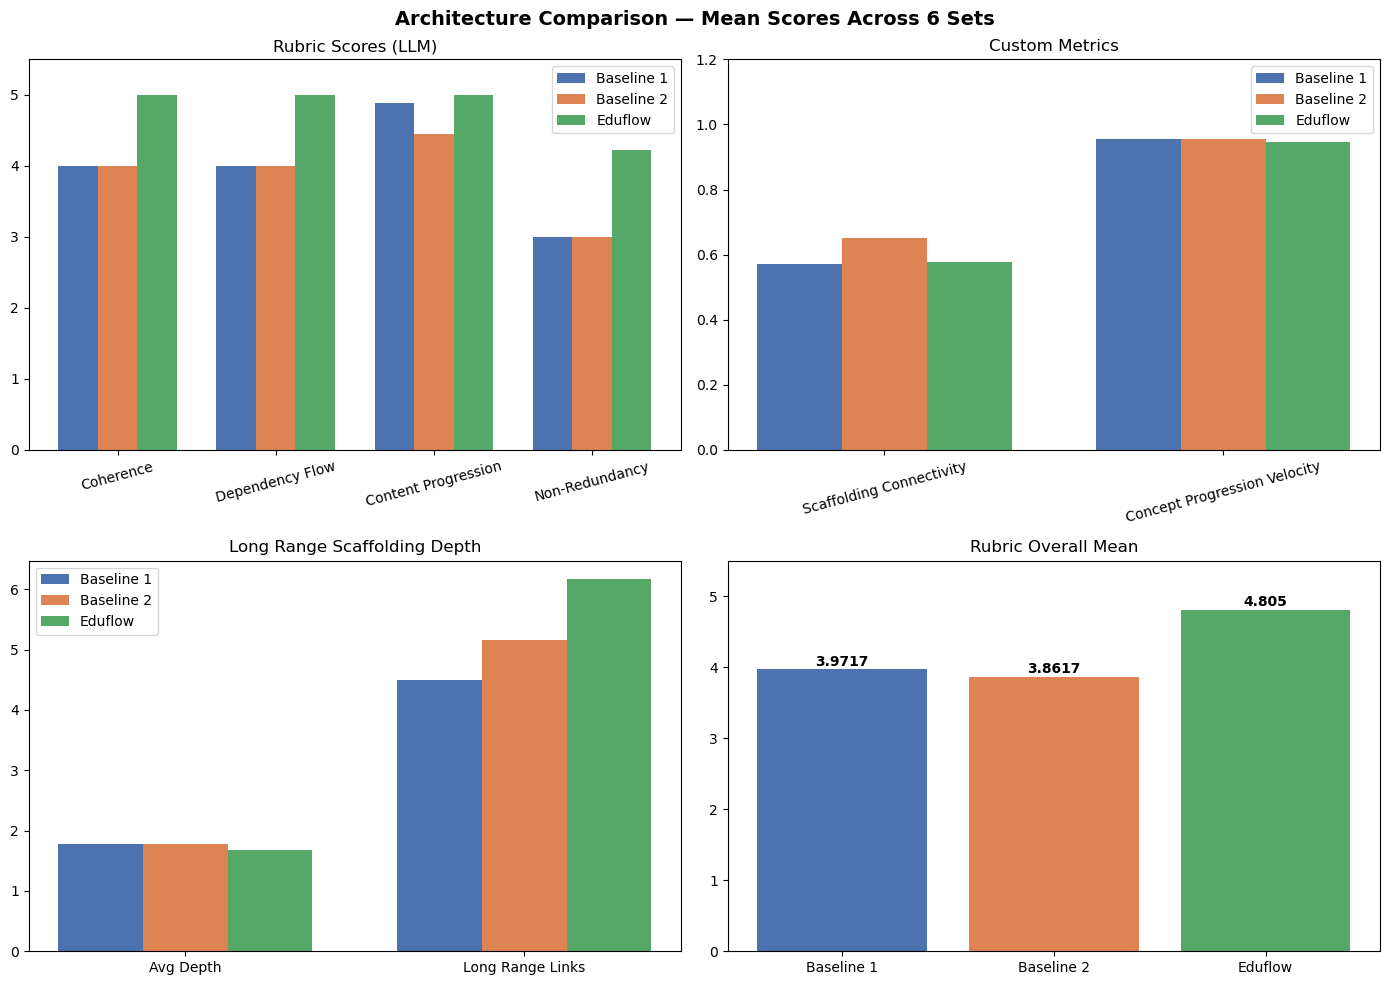

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Architecture Comparison — Mean Scores Across 6 Sets", fontsize=14, fontweight="bold")

architectures = summary.index.tolist()
colors = ["#4C72B0", "#DD8452", "#55A868"]  # blue, orange, green

# --- Plot 1: Rubric Scores ---
ax1 = axes[0, 0]
rubric_cols = ["rubric_coherence", "rubric_dependency_flow", "rubric_content_progression", "rubric_non_redundancy"]
rubric_labels = ["Coherence", "Dependency Flow", "Content Progression", "Non-Redundancy"]
x = np.arange(len(rubric_labels))
width = 0.25
for i, (arch, color) in enumerate(zip(architectures, colors)):
    ax1.bar(x + i * width, summary.loc[arch, rubric_cols], width, label=arch, color=color)
ax1.set_title("Rubric Scores (LLM)")
ax1.set_xticks(x + width)
ax1.set_xticklabels(rubric_labels, rotation=15)
ax1.set_ylim(0, 5.5)
ax1.legend()

# --- Plot 2: Custom Metrics ---
ax2 = axes[0, 1]
custom_cols = ["scs_overall", "cpv"]
custom_labels = ["Scaffolding Connectivity", "Concept Progression Velocity"]
x = np.arange(len(custom_labels))
for i, (arch, color) in enumerate(zip(architectures, colors)):
    ax2.bar(x + i * width, summary.loc[arch, custom_cols], width, label=arch, color=color)
ax2.set_title("Custom Metrics")
ax2.set_xticks(x + width)
ax2.set_xticklabels(custom_labels, rotation=15)
ax2.set_ylim(0, 1.2)
ax2.legend()

# --- Plot 3: Long Range Scaffolding ---
ax3 = axes[1, 0]
lrsd_cols = ["lrsd_avg_depth", "lrsd_long_range_links"]
lrsd_labels = ["Avg Depth", "Long Range Links"]
x = np.arange(len(lrsd_labels))
for i, (arch, color) in enumerate(zip(architectures, colors)):
    ax3.bar(x + i * width, summary.loc[arch, lrsd_cols], width, label=arch, color=color)
ax3.set_title("Long Range Scaffolding Depth")
ax3.set_xticks(x + width)
ax3.set_xticklabels(lrsd_labels)
ax3.legend()

# --- Plot 4: Rubric Overall Mean ---
ax4 = axes[1, 1]
ax4.bar(architectures, summary["rubric_overall_mean"], color=colors)
ax4.set_title("Rubric Overall Mean")
ax4.set_ylim(0, 5.5)
for i, v in enumerate(summary["rubric_overall_mean"]):
    ax4.text(i, v + 0.05, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

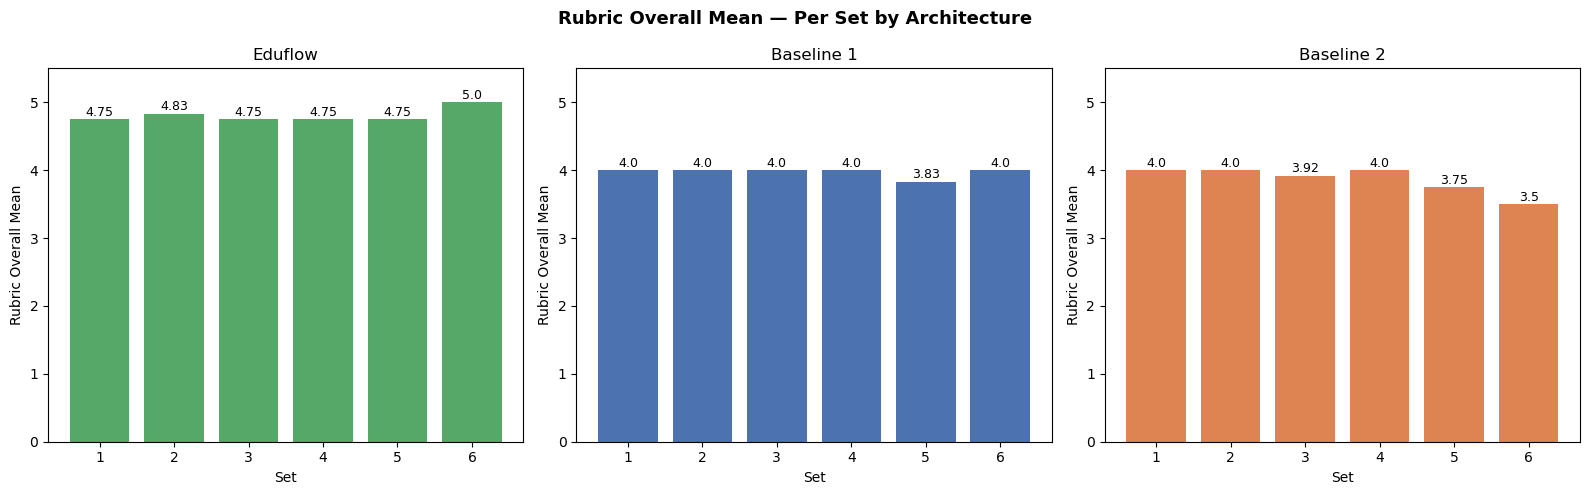

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Rubric Overall Mean — Per Set by Architecture", fontsize=13, fontweight="bold")

colors = {"Eduflow": "#55A868", "Baseline 1": "#4C72B0", "Baseline 2": "#DD8452"}
sets = [1, 2, 3, 4, 5, 6]

for ax, arch in zip(axes, ["Eduflow", "Baseline 1", "Baseline 2"]):
    subset = df[df["Architecture"] == arch].sort_values("Set")
    ax.bar(subset["Set"], subset["rubric_overall_mean"], color=colors[arch])
    ax.set_title(arch)
    ax.set_xlabel("Set")
    ax.set_ylabel("Rubric Overall Mean")
    ax.set_ylim(0, 5.5)
    ax.set_xticks(sets)
    for _, row in subset.iterrows():
        ax.text(row["Set"], row["rubric_overall_mean"] + 0.05, 
                str(round(row["rubric_overall_mean"], 2)), ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [11]:
pairwise_df = df[df["pairwise_parsed"].notna()].copy()

print("Pairwise winner distribution:")
print(pairwise_df.groupby(["Architecture", "pairwise_winner"]).size())

print("\nPer set pairwise results:")
print(pairwise_df[["Set", "Architecture", "pairwise_winner", "pairwise_consensus"]])

Pairwise winner distribution:
Architecture  pairwise_winner
Baseline 1    sequence_a         6
Baseline 2    sequence_a         6
dtype: int64

Per set pairwise results:
    Set Architecture pairwise_winner                  pairwise_consensus
1     1   Baseline 1      sequence_a  sequence_a wins with 100% win rate
2     1   Baseline 2      sequence_a  sequence_a wins with 100% win rate
4     2   Baseline 1      sequence_a  sequence_a wins with 100% win rate
5     2   Baseline 2      sequence_a  sequence_a wins with 100% win rate
7     3   Baseline 1      sequence_a  sequence_a wins with 100% win rate
8     3   Baseline 2      sequence_a  sequence_a wins with 100% win rate
10    4   Baseline 1      sequence_a  sequence_a wins with 100% win rate
11    4   Baseline 2      sequence_a  sequence_a wins with 100% win rate
13    5   Baseline 1      sequence_a  sequence_a wins with 100% win rate
14    5   Baseline 2      sequence_a  sequence_a wins with 100% win rate
16    6   Baseline 1      s

In [12]:
print("Token Usage by Architecture:")
token_summary = df.groupby("Architecture")[["Total Input Tokens", "Total Output Tokens"]].agg(["mean", "sum"]).round(0)
print(token_summary)

print("\nCompletion Time by Architecture:")
print(df.groupby("Architecture")["Completion Time"].agg(["mean", "min", "max"]).round(2))

Token Usage by Architecture:
             Total Input Tokens         Total Output Tokens       
                           mean     sum                mean    sum
Architecture                                                      
Baseline 1              29660.0  177959              4755.0  28531
Baseline 2              38460.0  230760              7444.0  44662
Eduflow                 40609.0  243655             10126.0  60753

Completion Time by Architecture:
                mean  min  max
Architecture                  
Baseline 1    112.33  106  119
Baseline 2    154.00  151  157
Eduflow       225.00  214  232


In [13]:
quality = df.groupby("Architecture")[["rubric_overall_mean", "scs_overall", "cpv", "lrsd_long_range_links"]].mean().round(4)
efficiency = df.groupby("Architecture")[["Total Input Tokens", "Total Output Tokens", "Completion Time"]].mean().round(0)

final_summary = pd.concat([quality, efficiency], axis=1)
final_summary.columns = [
    "Rubric Mean", "SCS", "CPV", "LR Links",
    "Avg Input Tokens", "Avg Output Tokens", "Avg Completion Time (s)"
]

# Add pairwise win rate
final_summary["Pairwise Win Rate"] = "N/A (reference)"
final_summary.loc["Baseline 1", "Pairwise Win Rate"] = "0/6 (0%)"
final_summary.loc["Baseline 2", "Pairwise Win Rate"] = "0/6 (0%)"

print(final_summary.to_string())

              Rubric Mean     SCS     CPV  LR Links  Avg Input Tokens  Avg Output Tokens  Avg Completion Time (s) Pairwise Win Rate
Architecture                                                                                                                       
Baseline 1         3.9717  0.5702  0.9562    4.5000           29660.0             4755.0                    112.0          0/6 (0%)
Baseline 2         3.8617  0.6511  0.9560    5.1667           38460.0             7444.0                    154.0          0/6 (0%)
Eduflow            4.8050  0.5767  0.9464    6.1667           40609.0            10126.0                    225.0   N/A (reference)


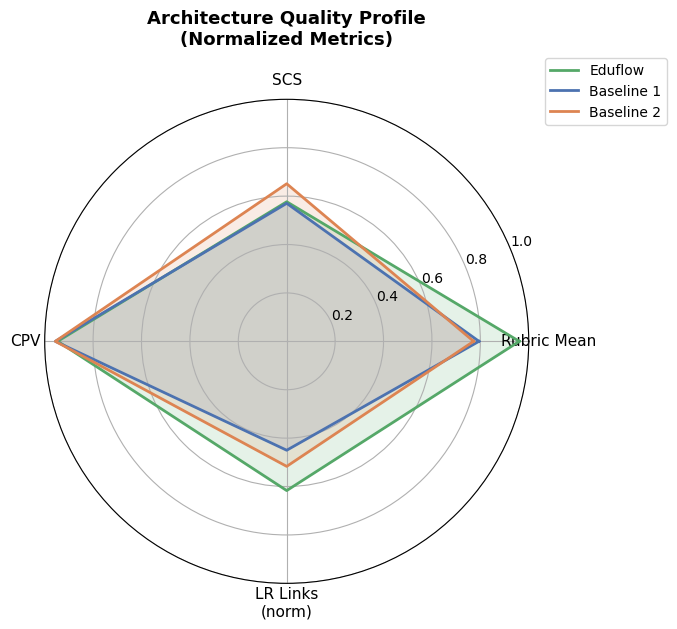

In [ ]:
# Normalize metrics to 0-1 scale for radar
metrics_radar = {
    "Rubric Mean":  {"Eduflow": 4.8050/5, "Baseline 1": 3.9717/5, "Baseline 2": 3.8617/5},
    "SCS":          {"Eduflow": 0.5767,   "Baseline 1": 0.5702,   "Baseline 2": 0.6511},
    "CPV":          {"Eduflow": 0.9464,   "Baseline 1": 0.9562,   "Baseline 2": 0.9560},
    "LR Links\n(norm)": {"Eduflow": 6.1667/10, "Baseline 1": 4.5/10, "Baseline 2": 5.1667/10},
}

labels = list(metrics_radar.keys())
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

colors = {"Eduflow": "#55A868", "Baseline 1": "#4C72B0", "Baseline 2": "#DD8452"}

for arch, color in colors.items():
    values = [metrics_radar[m][arch] for m in labels]
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, label=arch)
    ax.fill(angles, values, color=color, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title("Architecture Quality Profile\n(Normalized Metrics)", 
             fontsize=13, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()


In [ ]:
sys.path.append(os.path.abspath("../.."))

BASE_PATH = r"C:\Users\daves\Desktop\EduFlow\eduflow\evaluator_service\evaluation\downloaded_jobs"

word_counts = []

for _, row in df.iterrows():
    job_id = row["Job ID"]
    arch = row["Architecture"]
    set_num = row["Set"]
    pdf_folder = os.path.join(BASE_PATH, job_id, "pdf")
    
    if not os.path.exists(pdf_folder):
        print(f"⚠️ [{job_id}] pdf folder not found")
        continue

    pdfs = sorted([f for f in os.listdir(pdf_folder) if f.endswith(".pdf")])
    
    for pdf_file in pdfs:
        pdf_path = os.path.join(pdf_folder, pdf_file)
        # we'll use the already available extractor
        from evaluator_service.utils.pdf_extractor import extract_text_from_pdf
        text = extract_text_from_pdf(pdf_path)
        wc = len(text.split()) if text else 0
        word_counts.append({
            "Job ID": job_id,
            "Architecture": arch,
            "Set": set_num,
            "PDF": pdf_file,
            "Word Count": wc
        })

wc_df = pd.DataFrame(word_counts)
print(wc_df.groupby("Architecture")["Word Count"].agg(["mean", "min", "max"]).round(0))

                mean  min   max
Architecture                   
Baseline 1     671.0  556   759
Baseline 2     644.0  569   727
Eduflow       1120.0  856  1439


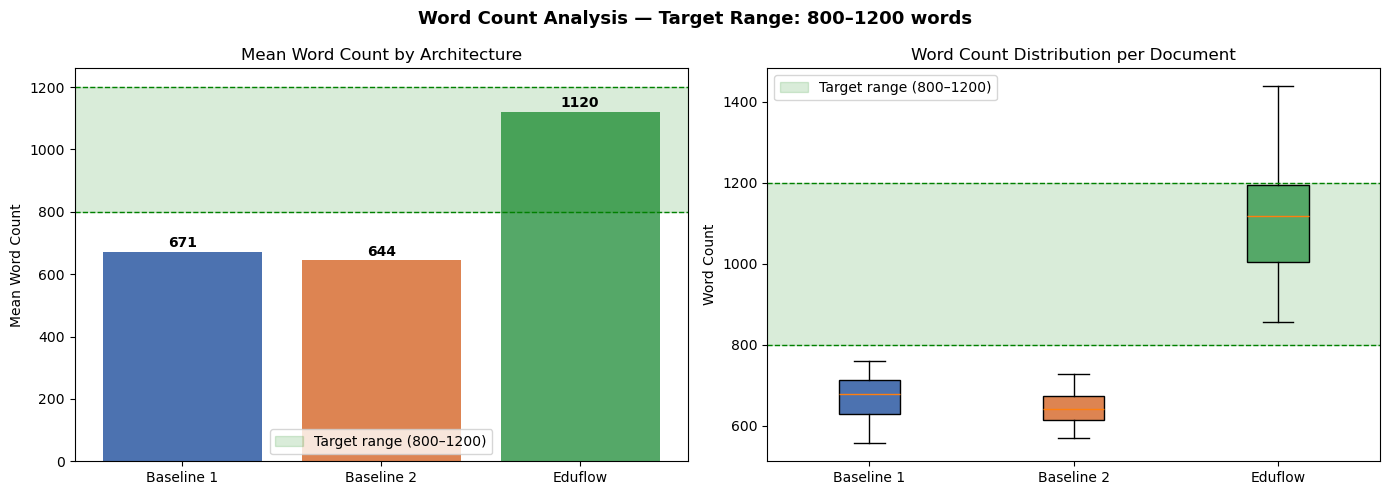

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Word Count Analysis — Target Range: 800–1200 words", fontsize=13, fontweight="bold")

colors = {"Eduflow": "#55A868", "Baseline 1": "#4C72B0", "Baseline 2": "#DD8452"}

# --- Plot 1: Mean word count per architecture with target band ---
ax1 = axes[0]
archs = ["Baseline 1", "Baseline 2", "Eduflow"]
means = [671, 644, 1120]
ax1.bar(archs, means, color=[colors[a] for a in archs])
ax1.axhspan(800, 1200, alpha=0.15, color="green", label="Target range (800–1200)")
ax1.axhline(800,  color="green", linestyle="--", linewidth=1)
ax1.axhline(1200, color="green", linestyle="--", linewidth=1)
for i, v in enumerate(means):
    ax1.text(i, v + 15, str(v), ha="center", fontweight="bold")
ax1.set_ylabel("Mean Word Count")
ax1.set_title("Mean Word Count by Architecture")
ax1.legend()

# --- Plot 2: Per doc distribution as boxplot ---
ax2 = axes[1]
data_to_plot = [wc_df[wc_df["Architecture"] == arch]["Word Count"].values for arch in archs]
bp = ax2.boxplot(data_to_plot, tick_labels=archs, patch_artist=True)
for patch, arch in zip(bp["boxes"], archs):
    patch.set_facecolor(colors[arch])
ax2.axhspan(800, 1200, alpha=0.15, color="green", label="Target range (800–1200)")
ax2.axhline(800,  color="green", linestyle="--", linewidth=1)
ax2.axhline(1200, color="green", linestyle="--", linewidth=1)
ax2.set_ylabel("Word Count")
ax2.set_title("Word Count Distribution per Document")
ax2.legend()

plt.tight_layout()
plt.show()